# Рубежный контроль №1 (весна 2025 года)
**Студент:** Ступницкий Михаил Сергеевич

**Группа:** ИУ5-64Б

|Номер задания|Номер задачи|Номер набора данных, указанного в задаче|
|:---:|:---:|:---:|
|15|2|7|

**Дополнительные требования:**
Для произвольной колонки данных построить график "Скрипичная диаграмма (violin plot)"

**Задача №2**  
Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

**Датасет**
https://www.kaggle.com/datasets/lava18/google-play-store-apps?select=googleplaystore.csv

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import *
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import LabelEncoder
%matplotlib inline 
sns.set(style="ticks")

## Загрузка данных

In [14]:
data = pd.read_csv('googleplaystore.csv', sep=",")

## Основные характеристики датасета

In [15]:
# Первые 5 строк датасета
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [16]:
# Размер датасета - 10841 строка, 13 колонок
data.shape

(10841, 13)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [18]:
total_count = data.shape[0]

In [19]:
data.isnull().sum() # пропуски в колонках Rating, Content Rating, Current Ver и Android Ver  

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [21]:
# Преобразуем Installs в числовой формат (удаляем '+', ',' и переводим в int)
data = data[data['Installs'] != 'Free']
data['Installs'] = data['Installs'].str.replace('[+,]', '', regex=True).astype(int)

# Создаем новый признак: Popularity = Rating * log(Installs + 1)
data['Popularity_Score'] = data['Rating'] * np.log10(data['Installs'] + 1)

# Проверяем результат
data[['Rating', 'Installs', 'Popularity_Score']].head()

,Rating,Installs,Popularity_Score
0,4.1,10000,16.400178
1,3.9,500000,22.225986
2,4.7,5000000,31.485159
3,4.5,50000000,34.645365
4,4.3,100000,21.500019


In [23]:
# Добавим искусственные пропуски для демонстрации, так как признак Rating целевой, в нем не будем заполнять пропуски
np.random.seed(42)
mask_quantitative = np.random.choice([True, False], size=len(data), p=[0.1, 0.9])

In [24]:
# добавляем пропуаски в искусственно созданную колонку
data.loc[mask_quantitative, 'Popularity_Score'] = np.nan

In [25]:
print("Данные с пропусками:")
print(data.isnull().sum())

Данные с пропусками:
App                    0
Category               0
Rating              1474
Reviews                0
Size                   0
Installs               0
Type                   1
Price                  0
Content Rating         0
Genres                 0
Last Updated           0
Current Ver            8
Android Ver            2
Popularity_Score    2441
dtype: int64


In [26]:
# Определим уникальные значения для категориальных признаков
data['Current Ver'].unique()

array(['1.0.0', '2.0.0', '1.2.4', ..., '1.0.612928', '0.3.4', '2.0.148.0'],
      dtype=object)

In [27]:
data['Popularity_Score'].unique()

array([16.40017805, 22.2259864 , 31.48515943, 34.64536506, 21.50001867,
       20.67550624,         nan, 24.60000178, 26.40000191, 18.80020411,
       29.40000018, 23.00001998, 22.00001911, 11.83698193, 26.7851631 ,
       18.00019542, 28.80557139, 32.2000002 , 20.00001737, 20.50001781,
       22.08519984, 19.20020845, 15.60016937, 21.00001824, 19.26581263,
       19.0000165 , 22.79588349, 16.80018239, 22.50001954, 32.9000002 ,
       24.00000174, 27.600002  , 19.50001694, 24.50002128, 18.40019977,
       25.80000187, 18.79591476, 28.13567438, 32.15505644, 20.51629514,
       24.00002085, 27.35506019, 21.61530197, 29.40000213, 18.32601689,
       22.20000161, 16.0000139 , 25.07547184, 23.40000169, 23.93567767,
       28.20000204, 17.60019108, 28.00000017, 23.36578058, 27.00000195,
       15.90594447, 36.80000002, 21.14540411, 30.80000019, 33.60000002,
       31.5000002 , 26.21526602, 28.80000208, 35.1       , 30.81526242,
       28.70000018, 19.80000143, 27.46577737, 25.64536893, 17.00

Целевым является признак Rating (задача регрессии)

## Обработка пустых значений

Категориальный признак

In [28]:
temp_null_count = data[data['Current Ver'].isnull()].shape[0]
dt = str(data['Current Ver'].dtype)
temp_perc = round((temp_null_count / total_count) * 100.0, 2)
print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format('Current Ver', dt, temp_null_count, temp_perc))

Колонка Current Ver. Тип данных object. Количество пустых значений 8, 0.07%.


In [29]:
# Обработка пропусков в категориальном признаке (мода)
mode_rating = data['Current Ver'].mode()[0]
print(f"Мода для Current Ver: {mode_rating}")
data['Current Ver'] = data['Current Ver'].fillna(mode_rating)

data[['Current Ver']]

Мода для Current Ver: Varies with device


,Current Ver
0,1.0.0
1,2.0.0
2,1.2.4
3,Varies with device
4,1.1
...,...
10836,1.48
10837,1.0
10838,1.0
10839,Varies with device


Количественный признак

In [30]:
temp_null_count = data[data['Popularity_Score'].isnull()].shape[0]
dt = str(data['Popularity_Score'].dtype)
temp_perc = round((temp_null_count / total_count) * 100.0, 2)
print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format('Popularity_Score', dt, temp_null_count, temp_perc))

Колонка Popularity_Score. Тип данных float64. Количество пустых значений 2441, 22.52%.


In [31]:
# Обработка пропусков в количественном признаке (медиана)
quantitative_imputer = SimpleImputer(strategy='median')
data['Popularity_Score'] = quantitative_imputer.fit_transform(
    data[['Popularity_Score']])

data[['Popularity_Score']]

,Popularity_Score
0,16.400178
1,22.225986
2,31.485159
3,34.645365
4,21.500019
...,...
10836,16.645756
10837,10.021607
10838,23.000020
10839,13.501953


Повторная проверка пустых значений

In [ ]:
print("\nДанные после обработки пропусков:") # Видим, что в колонках Popularity Score и Current Ver прпопусков нет
print(data.isnull().sum())


Данные после обработки пропусков:
App                    0
Category               0
Rating              1474
Reviews                0
Size                   0
Installs               0
Type                   1
Price                  0
Content Rating         0
Genres                 0
Last Updated           0
Current Ver            0
Android Ver            2
Popularity_Score       0
dtype: int64


In [33]:
# Признаки для построения моделей
features = ['Reviews', 'Installs', 
            'Size', 'Type', 'Category', 'Content Rating'
            ]

## Violin plot

 Violin plot отображает распределение данных, сочетая в себе box plot и ядерную оценку плотности (KDE).

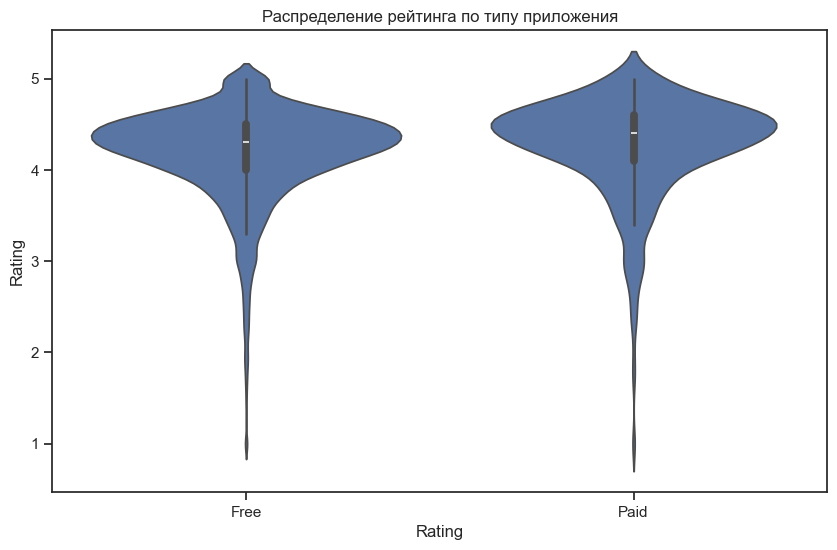

In [37]:
data_clean = data.dropna(subset=['Rating'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='Type', y='Rating', data=data_clean)
plt.title('Распределение рейтинга по типу приложения')
plt.xlabel('Rating')
plt.show()

## Ответы на вопросы

### Способы обработки пропусков

Для количественного признака была исользована методика импутации данных - "внедрения значений".

Для искусственного количественного признака Popularity Score использована стратегия медианы (strategy='median').

Причины выбора:

1. Медиана устойчива к выбросам
2. Сохраняет распределение признака
3. Не искажает статистические свойства данных

Для категориального признака Current Ver использован метод замены пустых значений рейтингом моды (Varies with device). 

Причины выбора:

1. Простота реализации

### Признаки для построения моделей

Выбранные признаки (features):
'Reviews', 'Installs', 'Size', 'Type', 'Category', 'Content Rating'

Целевой признак:

- Rating - количественный, непрерывный от 0 до 5.

Выбранные признаки хорошо описывают целевую переменную, не используются искусственные признаки и признаки
с необработанными пропусками

## Выводы

После проведения замены пустых значений модель может быть построена.